In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
from tensorflow import keras
from tensorflow.keras import layers
from IPython.display import display

2026-04-01 21:42:14.608120: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775079734.816940      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775079734.876724      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775079735.276912      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775079735.276949      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775079735.276952      55 computation_placer.cc:177] computation placer alr

In [2]:
CSV_PATH = "/kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-14-2018.csv" 
#SAMPLE_SIZE = len(pd.read_csv(CSV_PATH, usecols=[0]))
SAMPLE_SIZE=100000 
print(SAMPLE_SIZE)
BATCH_SIZE = 512
EPOCHS = 25
LEARNING_RATE = 1e-4


D_TOKEN = 192          
N_BLOCKS = 3           
ATTENTION_HEADS = 8    
DROPOUT = 0.1

100000


In [3]:
def load_and_clean_data(csv_path, sample_size=None):
    print(f"Loading data from {csv_path}...")
    
    df = pd.read_csv(csv_path, low_memory=False)
    display(df.describe())
   
    df = df[df['Dst Port'] != 'Dst Port']
    
    
    cols_to_numeric = df.columns.drop('Label')
    df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors='coerce')
    
    
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    df.dropna(axis=1, how='all', inplace=True) 
    
    print("Replacing NaN values with the mean of the column (Imputation)...")
    for col in df.columns.drop('Label'):
        if df[col].isnull().any():
            df[col].fillna(df[col].mean(), inplace=True)
            

    df.dropna(inplace=True)

    
    if sample_size and sample_size < len(df):
        print(f"Sampling {sample_size} records...")
        df = df.sample(n=sample_size, random_state=42)
        
    print(f"Data Loaded. Final Shape: {df.shape}")
    print(f"Class distribution:\n{df['Label'].value_counts()}")
    
    return df

In [4]:
path = CSV_PATH


full_cleaned_df = load_and_clean_data(path, sample_size=None)

print(f"Total cleaned rows available: {len(full_cleaned_df):,}")


df_check = full_cleaned_df.sample(n=100000, random_state=42)


leftover_df = full_cleaned_df.drop(df_check.index)


del full_cleaned_df 

features = df_check.columns.drop('Label')
    
print(f"File: {path}")
print(f"Number of Features: {len(features)}")
print(f"Feature Names: {list(features)}")
print("-" * 50)


print(f"Sampled Data (Going to model): {len(df_check):,} rows")
print(f"Leftover Data (Saved for end): {len(leftover_df):,} rows")

Loading data from /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-14-2018.csv...


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,...,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,4.876262e+03,8.107557e+00,6.255555e+06,6.206622e+00,7.211191e+00,4.479936e+02,4.521803e+03,1.745736e+02,8.389535e+00,3.879579e+01,...,2.793536e+00,2.327970e+01,5.152449e+04,2.136151e+04,8.789157e+04,3.995477e+04,3.101206e+06,7.297218e+05,4.812391e+06,2.126920e+06
std,1.444344e+04,4.460625e+00,1.260291e+09,4.447851e+01,1.048682e+02,1.573541e+04,1.515021e+05,2.876713e+02,1.948279e+01,5.331882e+01,...,5.557106e+00,1.106185e+01,5.815586e+05,2.186405e+05,7.395725e+05,5.602693e+05,5.414780e+08,3.820031e+08,1.522117e+09,1.817013e+07
min,0.000000e+00,0.000000e+00,-9.190110e+11,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.200000e+01,6.000000e+00,7.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.300000e+01,6.000000e+00,1.023000e+03,2.000000e+00,1.000000e+00,3.600000e+01,5.500000e+01,3.400000e+01,0.000000e+00,2.566667e+01,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,6.000000e+00,4.066690e+05,7.000000e+00,6.000000e+00,4.550000e+02,7.680000e+02,1.990000e+02,0.000000e+00,5.550000e+01,...,4.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553300e+04,1.700000e+01,1.200000e+08,5.115000e+03,9.198000e+03,8.591554e+06,1.339773e+07,6.444000e+04,1.460000e+03,1.121703e+04,...,1.031000e+03,4.800000e+01,1.102401e+08,5.723446e+07,1.102401e+08,1.102401e+08,3.394503e+11,2.432682e+11,9.797810e+11,1.260300e+10


Replacing NaN values with the mean of the column (Imputation)...


/tmp/ipykernel_55/3390531006.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


Data Loaded. Final Shape: (1048575, 79)
Class distribution:
Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64
Total cleaned rows available: 1,048,575
File: /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-14-2018.csv
Number of Features: 78
Feature Names: ['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pk

In [5]:
class FeatureTokenizer(layers.Layer):
    def __init__(self, num_features, d_token, **kwargs):
        super(FeatureTokenizer, self).__init__(**kwargs)
        
        self.num_features = num_features
        self.d_token = d_token

    def build(self, input_shape):
        self.feature_weights = self.add_weight(
            shape=(self.num_features, self.d_token),
            initializer="glorot_uniform",
            trainable=True,
        )
        self.feature_biases = self.add_weight(
            shape=(self.num_features, self.d_token),
            initializer="zeros",
            trainable=True,
        )
        self.cls_token = self.add_weight(
            shape=(1, 1, self.d_token),
            initializer="glorot_uniform",
            trainable=True,
        )
        super(FeatureTokenizer, self).build(input_shape)

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        x_expanded = tf.expand_dims(inputs, -1)
        tokens = x_expanded * self.feature_weights + self.feature_biases
        cls_tokens = tf.tile(self.cls_token, [batch_size, 1, 1])
        return tf.concat([cls_tokens, tokens], axis=1)

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_features": self.num_features,
            "d_token": self.d_token
        })
        return config


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, dropout_rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        # --- FIX: Store these as attributes for saving ---
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout_rate = dropout_rate
        
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(int(embed_dim * 1.33), activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dropout_rate": self.dropout_rate
        })
        return config

In [6]:
def build_ft_transformer(num_features, num_classes):
    inputs = layers.Input(shape=(num_features,))

    x = FeatureTokenizer(num_features, D_TOKEN)(inputs)

    for _ in range(N_BLOCKS):
        x = TransformerBlock(D_TOKEN, ATTENTION_HEADS, DROPOUT)(x)

    cls_output = x[:, 0, :] 
    
    x = layers.LayerNormalization()(cls_output)
    x = layers.ReLU()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model


In [7]:
if not os.path.exists(CSV_PATH):
    print(f"ERROR: File '{CSV_PATH}' not found. Please upload the data or update the path.")
    
else:
    
    print("Loading full dataset...")
    full_df = load_and_clean_data(CSV_PATH, sample_size=None)

    
    print(f"Sampling {SAMPLE_SIZE} records for the main pipeline...")
    df_sample = full_df.sample(n=SAMPLE_SIZE, random_state=42)
    leftover_df = full_df.drop(df_sample.index)

    print(f"Sampled Data Size: {len(df_sample):,} rows")
    print(f"Leftover Data Size: {len(leftover_df):,} rows\n")

    
    X = df_sample.drop(columns=['Label']).values
    y = df_sample['Label'].values

    
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    num_classes = len(le.classes_)
    num_features = X.shape[1]
    
    print(f"Total Features: {num_features}")
    print(f"Total Classes in Sample: {num_classes}")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

   
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )

    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
    train_ds = train_ds.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    
    test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
    test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    
    
    # 6. PROCESS LEFTOVER DATA 
    
    print("\nProcessing leftover data for final evaluation...")
    
    X_leftover = leftover_df.drop(columns=['Label'])
    y_leftover = leftover_df['Label']

    # SAFETY NET-unseen
    known_classes = set(le.classes_)
    valid_indices = y_leftover.isin(known_classes)
    X_leftover_valid = X_leftover[valid_indices].values
    y_leftover_valid = y_leftover[valid_indices].values

    dropped_rows = len(leftover_df) - len(X_leftover_valid)
    if dropped_rows > 0:
        print(f"Dropped {dropped_rows:,} leftover rows with unseen attack types to prevent encoder crash.")

    
    X_leftover_scaled = scaler.transform(X_leftover_valid)
    y_leftover_enc = le.transform(y_leftover_valid)

    
    leftover_ds = tf.data.Dataset.from_tensor_slices((X_leftover_scaled, y_leftover_enc))
    leftover_ds = leftover_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    
    del full_df

    print("\nData preparation complete. 'train_ds', 'test_ds', and 'leftover_ds' are ready!")

Loading full dataset...
Loading data from /kaggle/input/datasets/solarmainframe/ids-intrusion-csv/02-14-2018.csv...


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,...,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,4.876262e+03,8.107557e+00,6.255555e+06,6.206622e+00,7.211191e+00,4.479936e+02,4.521803e+03,1.745736e+02,8.389535e+00,3.879579e+01,...,2.793536e+00,2.327970e+01,5.152449e+04,2.136151e+04,8.789157e+04,3.995477e+04,3.101206e+06,7.297218e+05,4.812391e+06,2.126920e+06
std,1.444344e+04,4.460625e+00,1.260291e+09,4.447851e+01,1.048682e+02,1.573541e+04,1.515021e+05,2.876713e+02,1.948279e+01,5.331882e+01,...,5.557106e+00,1.106185e+01,5.815586e+05,2.186405e+05,7.395725e+05,5.602693e+05,5.414780e+08,3.820031e+08,1.522117e+09,1.817013e+07
min,0.000000e+00,0.000000e+00,-9.190110e+11,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.200000e+01,6.000000e+00,7.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.300000e+01,6.000000e+00,1.023000e+03,2.000000e+00,1.000000e+00,3.600000e+01,5.500000e+01,3.400000e+01,0.000000e+00,2.566667e+01,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,6.000000e+00,4.066690e+05,7.000000e+00,6.000000e+00,4.550000e+02,7.680000e+02,1.990000e+02,0.000000e+00,5.550000e+01,...,4.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553300e+04,1.700000e+01,1.200000e+08,5.115000e+03,9.198000e+03,8.591554e+06,1.339773e+07,6.444000e+04,1.460000e+03,1.121703e+04,...,1.031000e+03,4.800000e+01,1.102401e+08,5.723446e+07,1.102401e+08,1.102401e+08,3.394503e+11,2.432682e+11,9.797810e+11,1.260300e+10


Replacing NaN values with the mean of the column (Imputation)...


/tmp/ipykernel_55/3390531006.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


Data Loaded. Final Shape: (1048575, 79)
Class distribution:
Label
Benign            667626
FTP-BruteForce    193360
SSH-Bruteforce    187589
Name: count, dtype: int64
Sampling 100000 records for the main pipeline...
Sampled Data Size: 100,000 rows
Leftover Data Size: 948,575 rows

Total Features: 78
Total Classes in Sample: 3


I0000 00:00:1775079793.847197      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



Processing leftover data for final evaluation...

Data preparation complete. 'train_ds', 'test_ds', and 'leftover_ds' are ready!


In [8]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)


class_weights_dict = {i: weight for i, weight in enumerate(class_weights_array)}
print(f"Class Weights: {class_weights_dict}")

Class Weights: {0: np.float64(0.5264162241480282), 1: np.float64(1.7948890534203854), 2: np.float64(1.840857839753325)}


In [9]:

model = build_ft_transformer(num_features, num_classes)

model.summary()

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nStarting Training...")
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    class_weight=class_weights_dict
)

print("\nTraining Complete.")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_tokenizer               │ (None, 79, 192)        │        30,144 │
│ (FeatureTokenizer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 79, 192)        │     1,283,583 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 79, 192)        │     1,283,583 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 79, 192)        │     1,283,583 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_6           │ (None, 192)            │           384 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           579 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,881,856 (14.81 MB)

 Trainable params: 3,881,856 (14.81 MB)

 Non-trainable params: 0 (0.00 B)


Starting Training...
Epoch 1/25


I0000 00:00:1775079805.965586     124 service.cc:152] XLA service 0x7c60f000a5a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775079805.965619     124 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775079807.439794     124 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775079815.424637     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


157/157 ━━━━━━━━━━━━━━━━━━━━ 68s 320ms/step - accuracy: 0.9127 - loss: 0.2094 - val_accuracy: 0.9998 - val_loss: 7.8434e-04
Epoch 2/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 259ms/step - accuracy: 0.9993 - loss: 0.0028 - val_accuracy: 0.9988 - val_loss: 0.0038
Epoch 3/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 258ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9998 - val_loss: 8.6626e-04
Epoch 4/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 258ms/step - accuracy: 0.9999 - loss: 0.0011 - val_accuracy: 0.9998 - val_loss: 6.5783e-04
Epoch 5/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 258ms/step - accuracy: 0.9999 - loss: 8.5538e-04 - val_accuracy: 0.9998 - val_loss: 6.3339e-04
Epoch 6/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 258ms/step - accuracy: 0.9999 - loss: 8.0304e-04 - val_accuracy: 0.9998 - val_loss: 5.9561e-04
Epoch 7/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 258ms/step - accuracy: 0.9999 - loss: 7.6337e-04 - val_accuracy: 0.9999 - val_loss: 5.1593e-04
Epoch 8/25
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 258ms/step - a

In [10]:
from sklearn.metrics import f1_score

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1-Score on Test Set: {macro_f1:.10f}")



625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
Macro F1-Score on Test Set: 0.9999408174


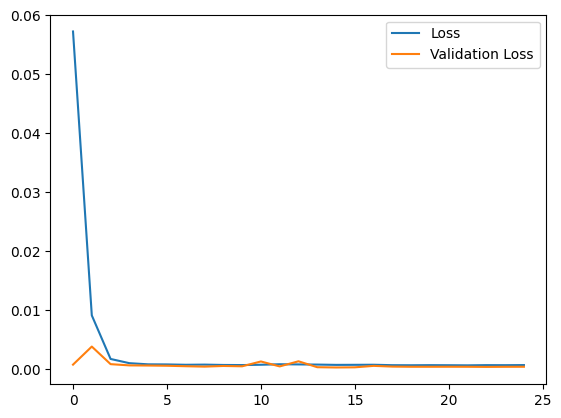

In [11]:

import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [12]:
model.save("/kaggle/working/ids_model.keras")

In [13]:
import json
import joblib


if 'reference_columns' in locals():
    feature_names = list(reference_columns)
else:
    
    feature_names = list(df_sample.columns.drop('Label'))

print(f"Found {len(feature_names)} Feature Names:")
print(feature_names)


class_names = list(le.classes_)
print(f"\nFound {len(class_names)} Class Names:")
print(class_names)


# 3. SAVE 



with open('model_columns.json', 'w') as f:
    json.dump(feature_names, f)
print("\nSaved 'model_columns.json'")


joblib.dump(le, 'label_encoder.joblib')
print("Saved 'label_encoder.joblib'")


joblib.dump(scaler, 'scaler.joblib')
print("Saved 'scaler.joblib'")


model.save('ids_model.keras')
print("Saved 'ids_model.keras'")

Found 78 Feature Names:
['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Av

In [14]:
print(len(X_train), len(X_test))

80000 20000


In [15]:
import numpy as np
from sklearn.metrics import classification_report, f1_score

print("      FINAL EVALUATION: LEFTOVER TRAFFIC          ")


print("Evaluating overall performance on leftover data...")
results = model.evaluate(leftover_ds, verbose=1)

print(f"\nLeftover Traffic Loss: {results[0]:.4f}")
print(f"Leftover Traffic Accuracy: {results[1]:.4f}")


print("\nGenerating detailed predictions...")
predictions = model.predict(leftover_ds)

predicted_classes = np.argmax(predictions, axis=1)


macro_f1 = f1_score(y_leftover_enc, predicted_classes, average='macro')
weighted_f1 = f1_score(y_leftover_enc, predicted_classes, average='weighted')

print(f"Leftover Traffic Macro F1: {macro_f1:.4f}")
print(f"Leftover Traffic Weighted F1: {weighted_f1:.4f}")

print("\n--- Detailed Classification Report (Leftover Data) ---")
print(classification_report(y_leftover_enc, predicted_classes, target_names=le.classes_))

      FINAL EVALUATION: LEFTOVER TRAFFIC          
Evaluating overall performance on leftover data...
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 142s 77ms/step - accuracy: 0.9999 - loss: 0.0012

Leftover Traffic Loss: 0.0007
Leftover Traffic Accuracy: 0.9999

Generating detailed predictions...
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 140s 75ms/step
Leftover Traffic Macro F1: 0.9999
Leftover Traffic Weighted F1: 0.9999

--- Detailed Classification Report (Leftover Data) ---
                precision    recall  f1-score   support

        Benign       1.00      1.00      1.00    604305
FTP-BruteForce       1.00      1.00      1.00    174788
SSH-Bruteforce       1.00      1.00      1.00    169482

      accuracy                           1.00    948575
     macro avg       1.00      1.00      1.00    948575
  weighted avg       1.00      1.00      1.00    948575



In [17]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

print("Calculating predictions for all splits (Train, Test, Leftover)...")

train_probs = model.predict(X_train, batch_size=BATCH_SIZE)
train_preds = np.argmax(train_probs, axis=1)
train_acc = accuracy_score(y_train, train_preds)
train_f1 = f1_score(y_train, train_preds, average='macro')

test_probs = model.predict(X_test, batch_size=BATCH_SIZE)
test_preds = np.argmax(test_probs, axis=1)
test_acc = accuracy_score(y_test, test_preds)
test_f1 = f1_score(y_test, test_preds, average='macro')

leftover_probs = model.predict(X_leftover_scaled, batch_size=BATCH_SIZE)
leftover_preds = np.argmax(leftover_probs, axis=1)
leftover_acc = accuracy_score(y_leftover_enc, leftover_preds)
leftover_f1 = f1_score(y_leftover_enc, leftover_preds, average='macro')

total_leftover = len(leftover_df)
leftover_counts = leftover_df['Label'].value_counts()

benign_leftover = leftover_counts.get('Benign', 0)
malicious_leftover = total_leftover - benign_leftover 

benign_leftover_pct = (benign_leftover / total_leftover) * 100
malicious_leftover_pct = (malicious_leftover / total_leftover) * 100

summary_data = {
    "Attack Included": ["FTP-Bruteforce, SSH-Bruteforce"],
    "Train Accuracy": [f"{train_acc:.4f}"],
    "Test Accuracy": [f"{test_acc:.4f}"],
    "Leftover Accuracy": [f"{leftover_acc:.4f}"],
    "Train F1 (Macro)": [f"{train_f1:.4f}"],
    "Test F1 (Macro)": [f"{test_f1:.4f}"],
    "Leftover F1 (Macro)": [f"{leftover_f1:.4f}"],
    "Sampled Instances (Train+Test)": ["100,000"],
    "Split (Train/Test)": ["80% / 20%"],
    "Leftover Instances": [f"{total_leftover:,}"],
    "Leftover Benign %": [f"{benign_leftover_pct:.2f}%"],
    "Leftover Malicious %": [f"{malicious_leftover_pct:.2f}%"]
}

summary_df = pd.DataFrame(summary_data)

display(summary_df)

Calculating predictions for all splits (Train, Test, Leftover)...
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 138s 75ms/step


,Attack Included,Train Accuracy,Test Accuracy,Leftover Accuracy,Train F1 (Macro),Test F1 (Macro),Leftover F1 (Macro),Sampled Instances (Train+Test),Split (Train/Test),Leftover Instances,Leftover Benign %,Leftover Malicious %
0,"FTP-Bruteforce, SSH-Bruteforce",1.0000,1.0000,0.9999,0.9999,0.9999,0.9999,"100,000",80% / 20%,"948,575",63.71%,36.29%
